In [1]:
# =============================================================================
# LOC_IF_SHAP_fix — Isolation Forest + SHAP for Hospital Outlier Detection
# =============================================================================
# This notebook is a methodological fix of LOC_IF_SHAP_v5.
# Each fix is annotated with # FIX #N: explaining what changed and why.
#
# Fixes applied:
#   1. Removed StandardScaler (IF doesn't need it; distorts SHAP interpretation)
#   2. Score-based 2σ threshold replaces fixed contamination=0.05
#   3. SHAP values now in original feature space (consequence of Fix #1)
#   4. Single pooled model trained on both years (cross-year comparability)
#   5. driver_dev_pct renamed/annotated — raw count space for log features
#   6. SQL HAVING clauses aligned (both use case_count >= 30)
#   7. 2026 month range limited to 202601–202604
# =============================================================================
from sqlalchemy import create_engine
from snowflake.sqlalchemy import URL
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import shap

c:\Users\knguy139\Documents\Projects\.venv\Lib\site-packages\snowflake\connector\vendored\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.7) doesn't match a supported version!
  warnings.warn(
c:\Users\knguy139\Documents\Projects\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# =============================================================================
# SNOWFLAKE CONNECTION
# =============================================================================
engine = create_engine(URL(
    account = "UHG-UHGDWAAS",
    user = "KHANG.NGUYEN@UHC.COM",
    authenticator = "externalbrowser",
    role = "AZU_SDRP_VING_PRD_DEVELOPER_ROLE",
    warehouse = "VING_PRD_MNR_HCE_DATAINFRA_WH",
    database = "VING_PRD_TREND_DB",
    schema = "TMP_1M"
))

In [3]:
# =============================================================================
# 2025 DATA PULL
# =============================================================================
# FIX #6: HAVING clause now uses count(distinct case_id) >= 30 (same as Python
#   eligibility filter). Previously v5's 2026 pull used a different HAVING on
#   ADR count, creating asymmetry. Both years now use identical SQL filters.
# =============================================================================
df_2025 = pd.read_sql("""
    select
        d.collection as hospital_group
        , a.fin_market
        , count(distinct a.case_id) as case_count
        , count(distinct case when a.initialfulladr_cases = 1 then a.case_id end) as initial_adr_cnt
        , count(distinct case when a.persistentfulladr_cases = 1 then a.case_id end) as persistent_adr_cnt
        , count(distinct case when a.p2p_full_ovtn = 1 then a.case_id end) as p2p_ovrtn_cnt
        , count(distinct case when a.appeal_ovrtn_ind = 1 then a.case_id end) as appeal_ovrtn_cnt
        , count(distinct case when a.mcr_ovtrn_ind = 1 then a.case_id end) as mcr_ovrtn_cnt
        , count(distinct case when a.icm_md_reviewed_ind = 1 then a.case_id end) as md_reviewed_cnt
    from tmp_1m.ec_avtar_25_26_3_od as a
    left join tmp_1y.tin_collection as d
        on substr(a.fa_prov_id, 2, 9) = d.tin
    where fin_brand = 'M&R'
        and (
            (ip_type in ('Medical', 'Surgical', 'Transplant')
             and to_varchar(admit_dt_act, 'MM/dd/yyyy') is not null)
            or ip_type in ('LTAC', 'SNF', 'AIR')
        )
        and loc_flag = 1
        and (
            (global_cap = 'NA' and sgr_source_name = 'COSMOS'
             and fin_product_level_3 != 'INSTITUTIONAL' and tfm_include_flag = 1)
            or (sgr_source_name = 'NICE' and nce_tadm_dec_risk_type in ('FFS', 'PHYSICIAN'))
        )
        and hce_admit_month between '202501' and '202512'
        and d.collection is not null
    group by 1,2
    having count(distinct a.case_id) >= 30
""", engine)

print(f"df_2025: {df_2025.shape}")

 pip install snowflake-connector-python[secure-local-storage]


Initiating login request with your identity provider. Press CTRL+C to abort and try again...
Going to open: https://login.microsoftonline.com/db05faca-c82a-4b9d-b9c5-0f64b6755421/saml2?SAMLRequest=lVJdb9owFP0rkfecxAkkBQuosiJaprZDfExdXybHdsBqYme%2BTkP36%2BcEkLqHVtqDJcs%2B555z77mT62NVeq%2FCgNRqiqIAI08oprlU%2BynabRf%2BCHlgqeK01EpM0ZsAdD2bAK3KmmSNPai1%2BN0IsJ4rpIB0H1PUGEU0BQlE0UoAsYxssod7EgeYUABhrJNDZwoH6bQO1tYkDNu2DdpBoM0%2BjDHGIR6HDtVBvqB3EvXnGrXRVjNdXihH19MHElGIh52EQziF1Zn4VarTCD5TyU8gIHfb7cpffd9skZddurvRCppKmI0wr5KJ3fr%2BZACcg%2Baw993hLaXw60ADULotSvoimK7qxrqagbuFheBhqffSTWo5n6L6RXJVH9LxY5bYJ7iFRPyha1Gs7%2BqU5gw%2FHWma3f5cPPBno77tGPJ%2BXHKNu1yXAI1Yqi5N655wnPo49aPRNhqR%2BIoMx8FgMH5G3tylKRW1PfNiufcRVJIZDbqwWpVSid4lz3FSUEZ9NoqpP8zH3M%2FHLPFxkQ7z9CpJhnEUdpnF6LQ3pDdiZv83jUn4nntewEeXyXK%2B0qVkb95Cm4rajyOLgqh%2FkdwveigRFZVlxrkRAC66stTtjRHUuj23phEonJ1U%2F9302V8%3D&RelayState=ver%3A3-hint%3A260092117886646-ETMsDgAAAZ7b%2FUXbABRBRVMvQ0JDL1BLQ1M1UGFkZGluZwEAABAAEHqltLB29QYI2TwcCWdFjw4AAACQGYAqyUby

In [4]:
# =============================================================================
# 2026 DATA PULL
# =============================================================================
# FIX #6: HAVING aligned to count(distinct case_id) >= 30 (was HAVING on ADR
#   count in v5). Python eligibility filter is still the binding one.
# FIX #7: Month range limited to 202601–202604 (was open-ended >= '202601').
# =============================================================================
df_2026 = pd.read_sql("""
    select
        d.collection as hospital_group
        , a.fin_market
        , count(distinct a.case_id) as case_count
        , count(distinct case when a.initialfulladr_cases = 1 then a.case_id end) as initial_adr_cnt
        , count(distinct case when a.persistentfulladr_cases = 1 then a.case_id end) as persistent_adr_cnt
        , count(distinct case when a.p2p_full_ovtn = 1 then a.case_id end) as p2p_ovrtn_cnt
        , count(distinct case when a.appeal_ovrtn_ind = 1 then a.case_id end) as appeal_ovrtn_cnt
        , count(distinct case when a.mcr_ovtrn_ind = 1 then a.case_id end) as mcr_ovrtn_cnt
        , count(distinct case when a.icm_md_reviewed_ind = 1 then a.case_id end) as md_reviewed_cnt
        , count(distinct case when a.member_appeal_ind = 1 then a.case_id end) as member_appeal_cnt
        , count(distinct case when a.member_appeal_ovtn_ind = 1 then a.case_id end) as member_appeal_ovtn_cnt
    from tmp_1m.ec_avtar_25_26_3_od as a
    left join tmp_1y.tin_collection as d
        on substr(a.fa_prov_id, 2, 9) = d.tin
    where fin_brand = 'M&R'
        and (
            (ip_type in ('Medical', 'Surgical', 'Transplant')
             and to_varchar(admit_dt_act, 'MM/dd/yyyy') is not null)
            or ip_type in ('LTAC', 'SNF', 'AIR')
        )
        and loc_flag = 1
        and (
            (global_cap = 'NA' and sgr_source_name = 'COSMOS'
             and fin_product_level_3 != 'INSTITUTIONAL' and tfm_include_flag = 1)
            or (sgr_source_name = 'NICE' and nce_tadm_dec_risk_type in ('FFS', 'PHYSICIAN'))
        )
        and hce_admit_month between '202601' and '202604'
        and d.collection is not null
    group by 1,2
    having count(distinct a.case_id) >= 30
""", engine)

engine.dispose()
print(f"df_2026: {df_2026.shape}")

df_2026: (1026, 11)


In [5]:
# =============================================================================
# COMPUTE RATES + EMPIRICAL BAYES SHRINKAGE + LOG-VOLUME (both years)
# =============================================================================

def compute_rates_and_shrinkage(df, year, has_member_appeal = False):
    df = df.assign(
        initial_adr_rate = lambda x: x.initial_adr_cnt / x.case_count,
        persistent_adr_rate = lambda x: x.persistent_adr_cnt / x.case_count,
        p2p_overturn_rate = lambda x: x.p2p_ovrtn_cnt / x.initial_adr_cnt.replace(0, np.nan),
        appeal_overturn_rate = lambda x: x.appeal_ovrtn_cnt / x.initial_adr_cnt.replace(0, np.nan),
        mcr_overturn_rate = lambda x: x.mcr_ovrtn_cnt / x.initial_adr_cnt.replace(0, np.nan),
        md_review_rate = lambda x: x.md_reviewed_cnt / x.case_count,
    )
    if has_member_appeal:
        df = df.assign(
            member_appeal_rate = lambda x: x.member_appeal_cnt / x.initial_adr_cnt.replace(0, np.nan),
        )

    rate_cols = [
        "initial_adr_rate", "persistent_adr_rate", "p2p_overturn_rate",
        "appeal_overturn_rate", "mcr_overturn_rate", "md_review_rate",
    ]
    if has_member_appeal:
        rate_cols.append("member_appeal_rate")

    count_cols = [
        "case_count", "initial_adr_cnt", "persistent_adr_cnt",
        "p2p_ovrtn_cnt", "appeal_ovrtn_cnt", "mcr_ovrtn_cnt", "md_reviewed_cnt"
    ]
    if has_member_appeal:
        count_cols += ["member_appeal_cnt", "member_appeal_ovtn_cnt"]

    df[rate_cols + count_cols] = df[rate_cols + count_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

    df_iso = df.query("case_count >= 30 and initial_adr_cnt >= 10").copy()
    raw_medians = df_iso[rate_cols].median()

    k = 50
    gr_initial_adr = df_iso["initial_adr_cnt"].sum() / df_iso["case_count"].sum()
    gr_persistent = df_iso["persistent_adr_cnt"].sum() / df_iso["case_count"].sum()
    gr_p2p = df_iso["p2p_ovrtn_cnt"].sum() / df_iso["initial_adr_cnt"].sum()
    gr_appeal = df_iso["appeal_ovrtn_cnt"].sum() / df_iso["initial_adr_cnt"].sum()
    gr_mcr = df_iso["mcr_ovrtn_cnt"].sum() / df_iso["initial_adr_cnt"].sum()
    gr_md = df_iso["md_reviewed_cnt"].sum() / df_iso["case_count"].sum()

    df_iso = df_iso.assign(
        initial_adr_adj_rate = lambda x: (x.initial_adr_cnt + k * gr_initial_adr) / (x.case_count + k),
        persistent_adr_adj_rate = lambda x: (x.persistent_adr_cnt + k * gr_persistent) / (x.case_count + k),
        p2p_overturn_adj_rate = lambda x: (x.p2p_ovrtn_cnt + k * gr_p2p) / (x.initial_adr_cnt + k),
        appeal_overturn_adj_rate = lambda x: (x.appeal_ovrtn_cnt + k * gr_appeal) / (x.initial_adr_cnt + k),
        mcr_overturn_adj_rate = lambda x: (x.mcr_ovrtn_cnt + k * gr_mcr) / (x.initial_adr_cnt + k),
        md_review_adj_rate = lambda x: (x.md_reviewed_cnt + k * gr_md) / (x.case_count + k),
        log_case_count = lambda x: np.log1p(x.case_count),
        log_initial_adr_cnt = lambda x: np.log1p(x.initial_adr_cnt),
    )
    if has_member_appeal:
        gr_member_appeal = df_iso["member_appeal_cnt"].sum() / df_iso["initial_adr_cnt"].sum()
        df_iso = df_iso.assign(
            member_appeal_adj_rate = lambda x: (x.member_appeal_cnt + k * gr_member_appeal) / (x.initial_adr_cnt + k),
        )

    df_iso["year"] = year
    return df_iso, raw_medians, rate_cols, count_cols

df_iso_25, raw_medians_25, rate_cols_25, count_cols_25 = compute_rates_and_shrinkage(df_2025, "2025", has_member_appeal = False)
df_iso_26, raw_medians_26, rate_cols_26, count_cols_26 = compute_rates_and_shrinkage(df_2026, "2026", has_member_appeal = True)

print(f"2025 IF-ready: {df_iso_25.shape[0]} hospitals")
print(f"2026 IF-ready: {df_iso_26.shape[0]} hospitals")

2025 IF-ready: 1226 hospitals
2026 IF-ready: 790 hospitals


In [6]:
# =============================================================================
# FIX #4: SINGLE POOLED MODEL — train one IF on both years combined
# =============================================================================
# WHY: In v5, each year had its own IF model with its own decision boundaries.
#   A hospital ranked #3 in 2025 and #3 in 2026 isn't equally anomalous because
#   the score distributions differ. A pooled model ensures scores are on the
#   same scale and cross-year comparisons are valid.
#
# APPROACH: Use the shared feature set (8 features). member_appeal_adj_rate is
#   set to 0 for 2025 since it's not available (equivalent to "no signal").
#   This is acceptable because the Bayes-shrunk rate for a hospital with 0
#   member appeals would converge toward the global rate × k/(n+k) ≈ a small
#   number anyway.
# =============================================================================

iso_kpi = [
    "log_case_count", "log_initial_adr_cnt",
    "initial_adr_adj_rate", "persistent_adr_adj_rate", "p2p_overturn_adj_rate",
    "appeal_overturn_adj_rate", "mcr_overturn_adj_rate", "md_review_adj_rate",
    "member_appeal_adj_rate"
]

for col in iso_kpi:
    if col not in df_iso_25.columns:
        df_iso_25[col] = 0.0
    if col not in df_iso_26.columns:
        df_iso_26[col] = 0.0

df_pooled = pd.concat([df_iso_25, df_iso_26], ignore_index = False)
df_pooled[iso_kpi] = df_pooled[iso_kpi].replace([np.inf, -np.inf], np.nan).fillna(0)

print(f"Pooled: {df_pooled.shape[0]} hospital-years, {len(iso_kpi)} features")
print(f"  2025: {(df_pooled['year'] == '2025').sum()}")
print(f"  2026: {(df_pooled['year'] == '2026').sum()}")

Pooled: 2016 hospital-years, 9 features
  2025: 1226
  2026: 790


In [7]:
# =============================================================================
# FIX #1: NO StandardScaler — Isolation Forest does NOT need scaling
# =============================================================================
# WHY: IF splits on individual features independently (like any decision tree).
#   It doesn't compute distances between points, so scale differences across
#   features don't affect split quality. StandardScaler was distorting SHAP
#   interpretation — SHAP values were in z-score space while reported driver
#   values were in original units. Without scaling, SHAP values are directly
#   interpretable in the original feature space.
#
# FIX #3: SHAP IN ORIGINAL FEATURE SPACE — consequence of removing scaling.
#   Now shap_driver_value and driver_actual_value are on the same scale.
# =============================================================================
# FIX #2: SCORE-BASED 2σ THRESHOLD replaces contamination=0.05
# =============================================================================
# WHY: Fixed contamination tells the model "always flag exactly 5%" regardless
#   of whether the year is genuinely homogeneous or chaotic. With 2σ, the
#   threshold adapts: homogeneous years flag fewer, chaotic years flag more.
#   This means the flagged list represents "statistically unusual" rather than
#   "the top 5% by construction."
#
# HOW: Set contamination='auto' (sklearn default, no forced threshold), then
#   flag hospitals whose anomaly score < mean(scores) - 2*std(scores).
# =============================================================================

X_pooled = df_pooled[iso_kpi].values

iso_model = IsolationForest(contamination = "auto", n_estimators = 300, random_state = 42)
iso_model.fit(X_pooled)

scores = iso_model.decision_function(X_pooled)
score_mean = scores.mean()
score_std = scores.std()
threshold = score_mean - 2 * score_std

df_pooled = df_pooled.assign(
    anomaly_score = scores,
    anomaly_flag = scores < threshold,
)
df_pooled["anomaly_rank"] = df_pooled["anomaly_score"].rank(method = "dense", ascending = True).astype(int)
df_pooled["percentile_rank"] = df_pooled["anomaly_score"].rank(pct = True).round(4)

flagged_total = df_pooled["anomaly_flag"].sum()
flagged_25 = ((df_pooled["year"] == "2025") & df_pooled["anomaly_flag"]).sum()
flagged_26 = ((df_pooled["year"] == "2026") & df_pooled["anomaly_flag"]).sum()

print(f"Score threshold (mean - 2σ): {threshold:.4f}")
print(f"Flagged: {flagged_total} / {df_pooled.shape[0]} total ({flagged_total / df_pooled.shape[0] * 100:.1f}%)")
print(f"  2025: {flagged_25} | 2026: {flagged_26}")

Score threshold (mean - 2σ): -0.0266
Flagged: 99 / 2016 total (4.9%)
  2025: 66 | 2026: 33


In [8]:
# =============================================================================
# SHAP EXPLAINER (pooled model)
# =============================================================================
explainer = shap.TreeExplainer(iso_model)
shap_values_raw = explainer.shap_values(X_pooled)

if isinstance(shap_values_raw, list):
    shap_values = np.array(shap_values_raw[0], dtype=float)
else:
    shap_values = np.array(shap_values_raw, dtype=float)

if shap_values.ndim == 1:
    shap_values = shap_values.reshape(1, -1)

assert shap_values.ndim == 2, f"Expected 2D shap_values, got shape {shap_values.shape}"
assert shap_values.shape == X_pooled.shape, f"Shape mismatch: shap {shap_values.shape} vs X {X_pooled.shape}"

print(f"SHAP values shape: {shap_values.shape}")

SHAP values shape: (2016, 9)


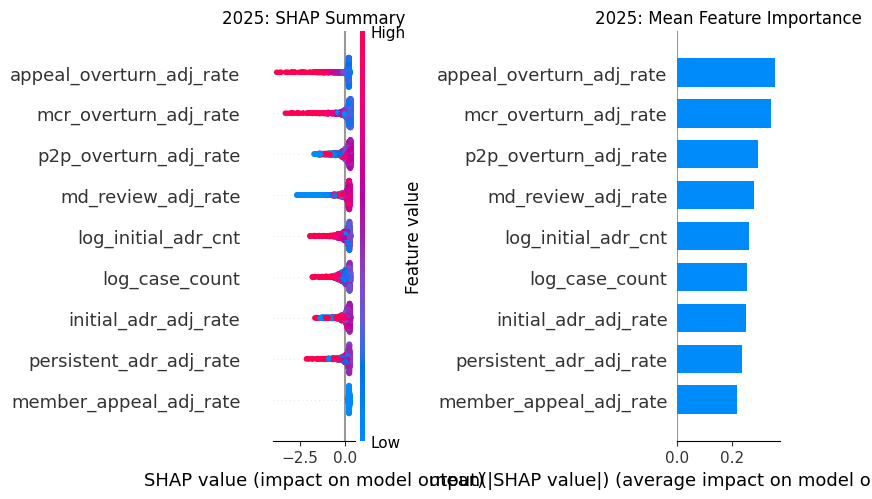

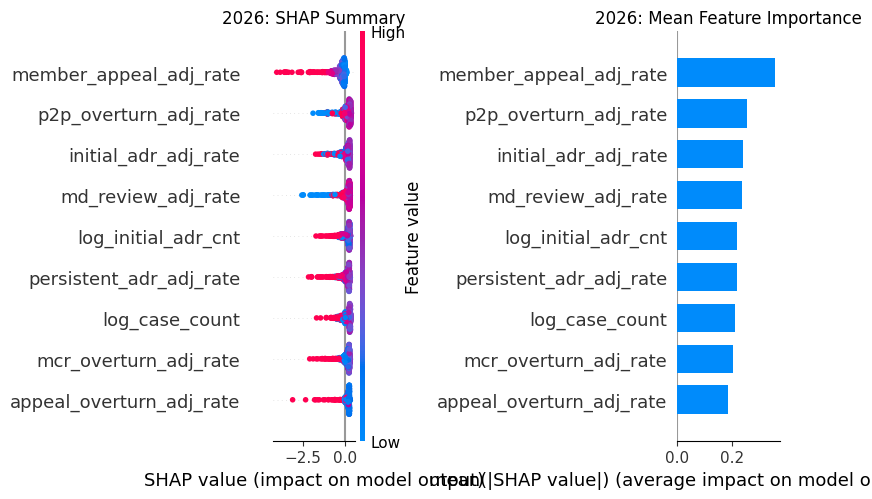

In [9]:
# =============================================================================
# SHAP SUMMARY PLOTS — split by year for readability
# =============================================================================
for yr in ["2025", "2026"]:
    mask = (df_pooled["year"] == yr).values
    fig, axes = plt.subplots(1, 2, figsize = (16, 5))

    plt.sca(axes[0])
    shap.summary_plot(shap_values[mask], X_pooled[mask], feature_names = iso_kpi, show = False)
    axes[0].set_title(f"{yr}: SHAP Summary")

    plt.sca(axes[1])
    shap.summary_plot(shap_values[mask], X_pooled[mask], feature_names = iso_kpi, plot_type = "bar", show = False)
    axes[1].set_title(f"{yr}: Mean Feature Importance")

    plt.tight_layout()
    plt.show()

In [12]:
# =============================================================================
# SHAP FLAGGED HOSPITAL DRIVERS
# =============================================================================
flagged_mask = df_pooled["anomaly_flag"].values
flagged_pos = np.where(flagged_mask)[0]

shap_flagged = pd.DataFrame(
    shap_values[flagged_pos, :],
    columns=iso_kpi,
    index=df_pooled.index[flagged_pos]
)
shap_flagged["hospital_group"] = df_pooled.iloc[flagged_pos]["hospital_group"].values
shap_flagged["fin_market"] = df_pooled.iloc[flagged_pos]["fin_market"].values
shap_flagged["year"] = df_pooled.iloc[flagged_pos]["year"].values
shap_flagged["anomaly_rank"] = df_pooled.iloc[flagged_pos]["anomaly_rank"].values

shap_flagged["shap_driver"] = shap_flagged[iso_kpi].idxmin(axis=1)
shap_flagged["shap_driver_value"] = shap_flagged[iso_kpi].min(axis=1)
shap_flagged["driver_actual_value"] = shap_flagged.apply(
    lambda r: df_pooled.iloc[flagged_pos][r["shap_driver"]].loc[r.name], axis=1
)

print(f"Flagged: {len(shap_flagged)} hospital-years")
shap_flagged[["hospital_group", "fin_market", "year", "anomaly_rank", "shap_driver", "shap_driver_value", "driver_actual_value"]].sort_values("anomaly_rank")

Flagged: 99 hospital-years


,hospital_group,fin_market,year,anomaly_rank,shap_driver,shap_driver_value,driver_actual_value
862,Atrium Health System,NC,2026,1,member_appeal_adj_rate,-3.336902,0.651464
419,ADVOCATE HEALTH & HOSPITALS IL,IL,2026,2,md_review_adj_rate,-2.042879,0.030516
334,NORTH CAROLINA BAPTIST HOSPITAL SYSTEM,NC,2026,3,member_appeal_adj_rate,-3.557558,0.631091
778,Ascension MI,MI,2025,4,md_review_adj_rate,-1.857483,0.1351
572,JOHNS HOPKINS HEALTH SYSTEM,DC,2025,5,appeal_overturn_adj_rate,-2.833481,0.049326
...,...,...,...,...,...,...,...
64,TENET HEALTHCARE CORPORATION,CA-S,2025,95,mcr_overturn_adj_rate,-2.896002,0.106675
818,WYCKOFF MEDICAL CENTER,NY,2025,96,mcr_overturn_adj_rate,-2.117074,0.08145
63,Adventist Health System Florida,FL,2025,97,log_initial_adr_cnt,-1.840094,8.85152
650,VAIL CLINIC,CO,2025,98,appeal_overturn_adj_rate,-3.759616,0.051946



Ascension MI | Rank #4 (2025)


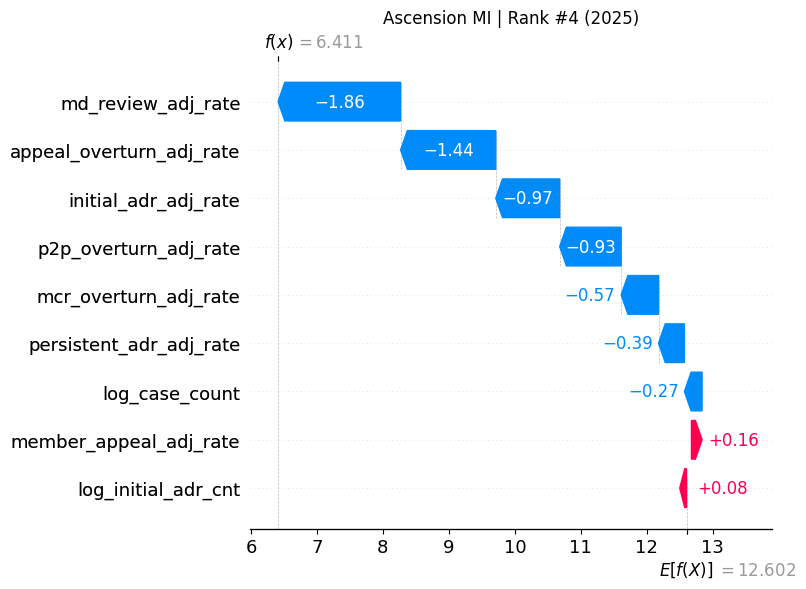


JOHNS HOPKINS HEALTH SYSTEM | Rank #5 (2025)


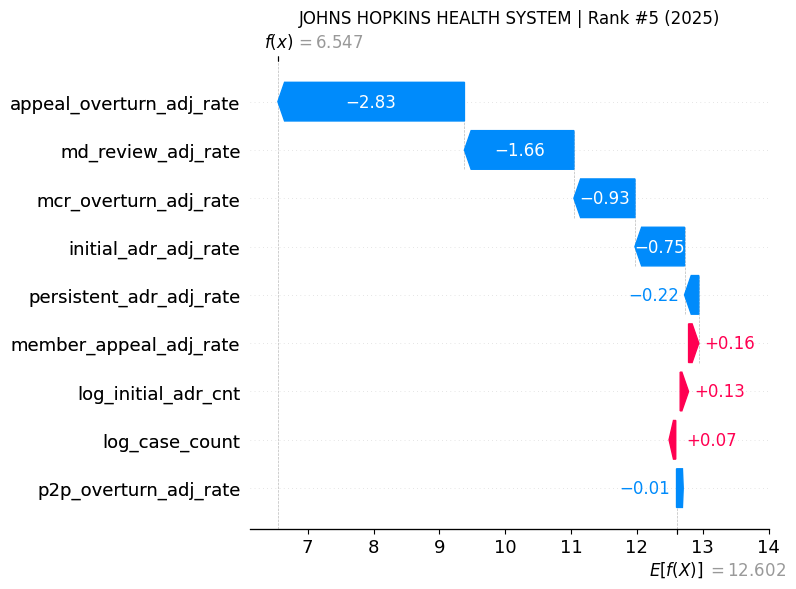


Froedtert | Rank #6 (2025)


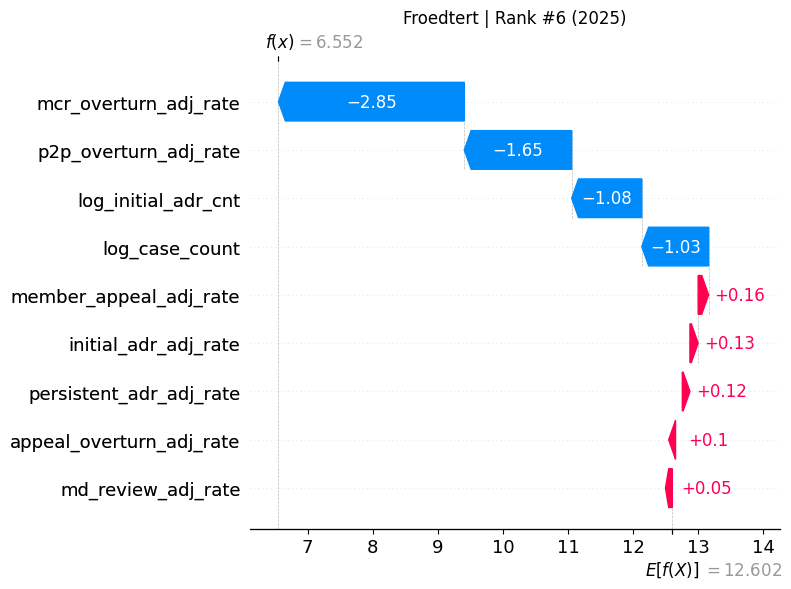


OKLAHOMA SPINE HOSPITAL | Rank #7 (2025)


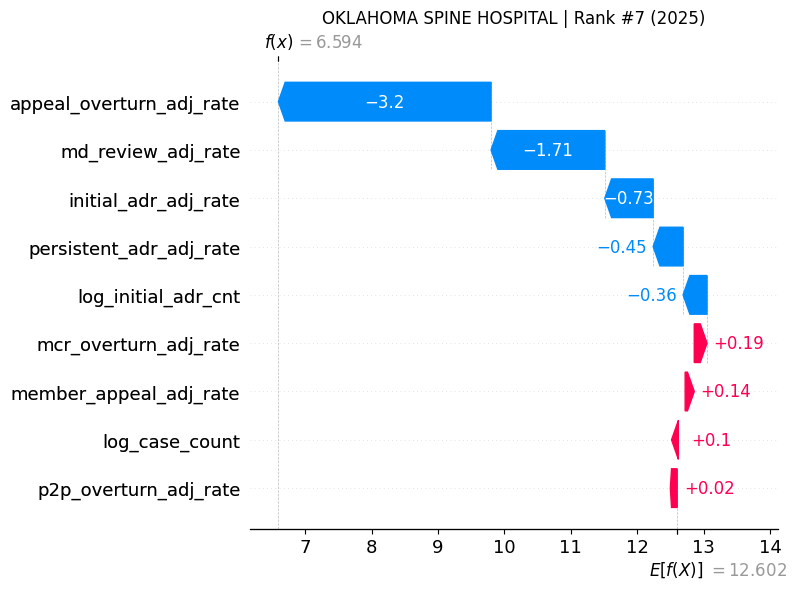


Steward | Rank #8 (2025)


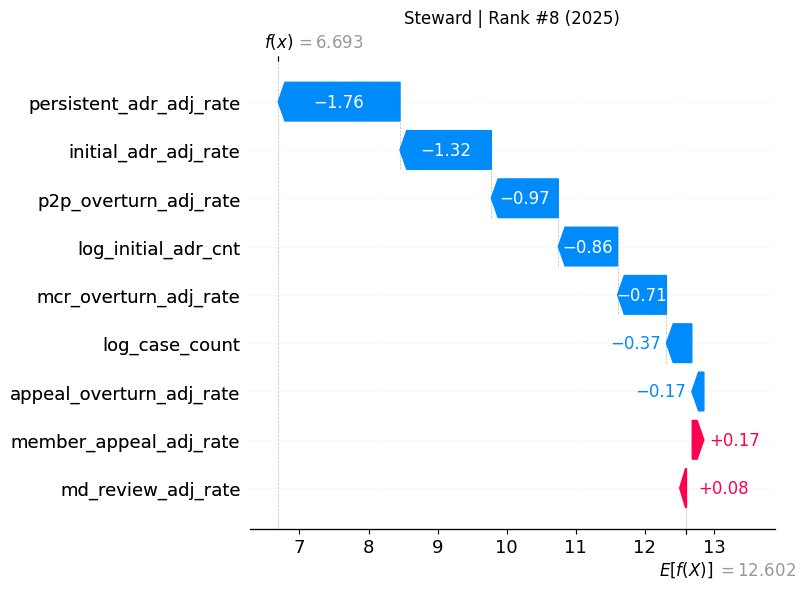


Atrium Health System | Rank #1 (2026)


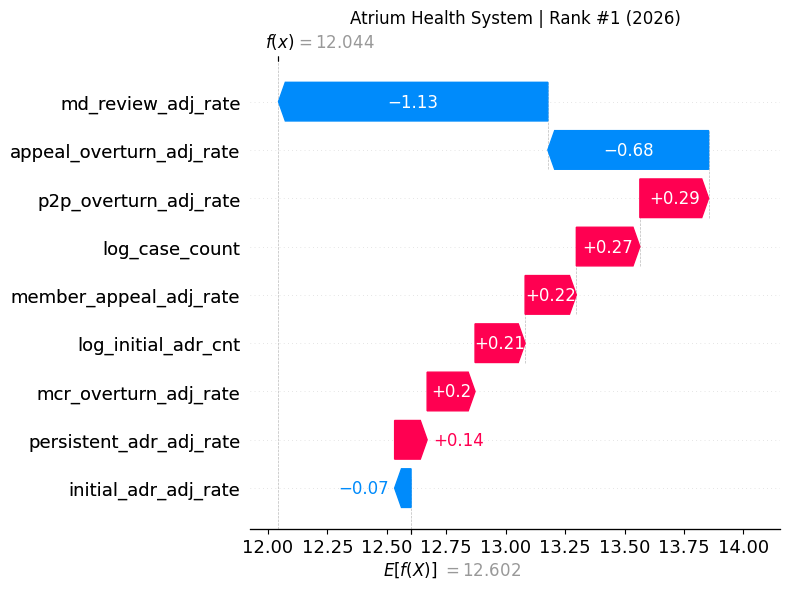


ADVOCATE HEALTH & HOSPITALS IL | Rank #2 (2026)


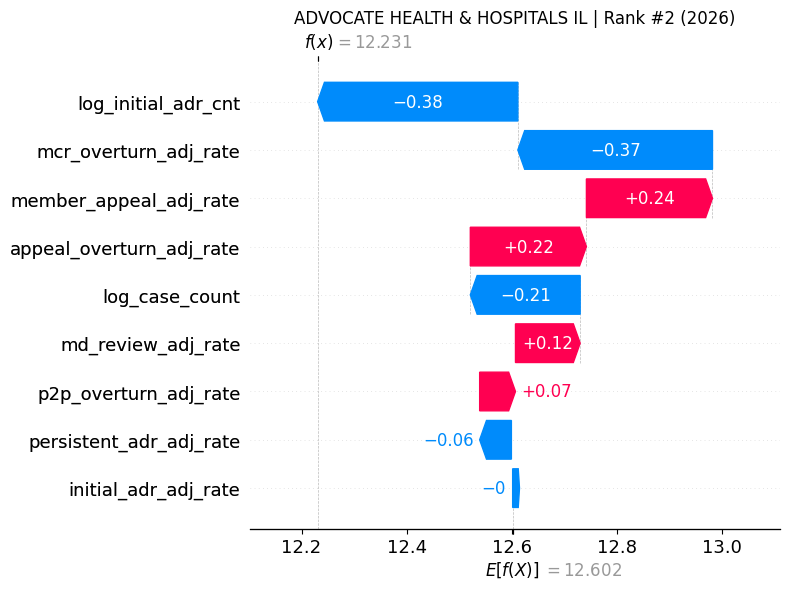


NORTH CAROLINA BAPTIST HOSPITAL SYSTEM | Rank #3 (2026)


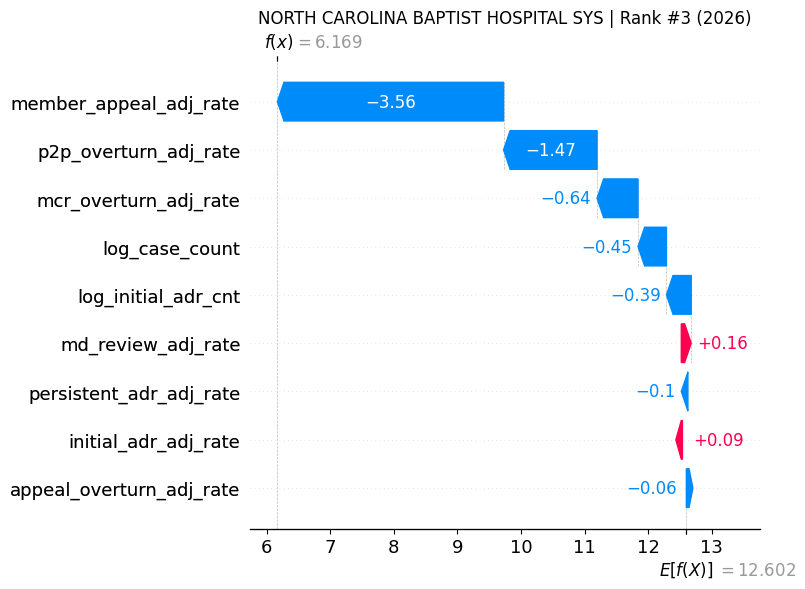


HEALTH SERVICES OF CENTRAL GA | Rank #9 (2026)


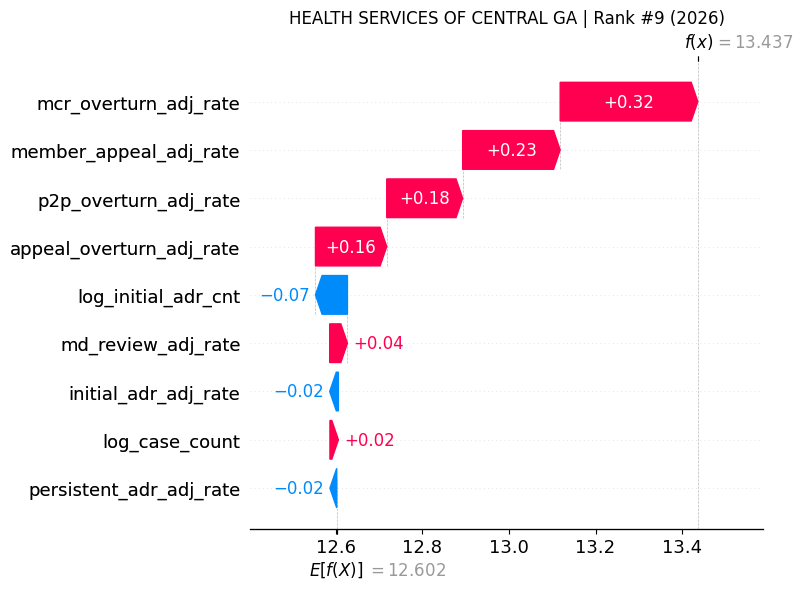


FLOYD HEALTHCARE MANAGEMENT | Rank #12 (2026)


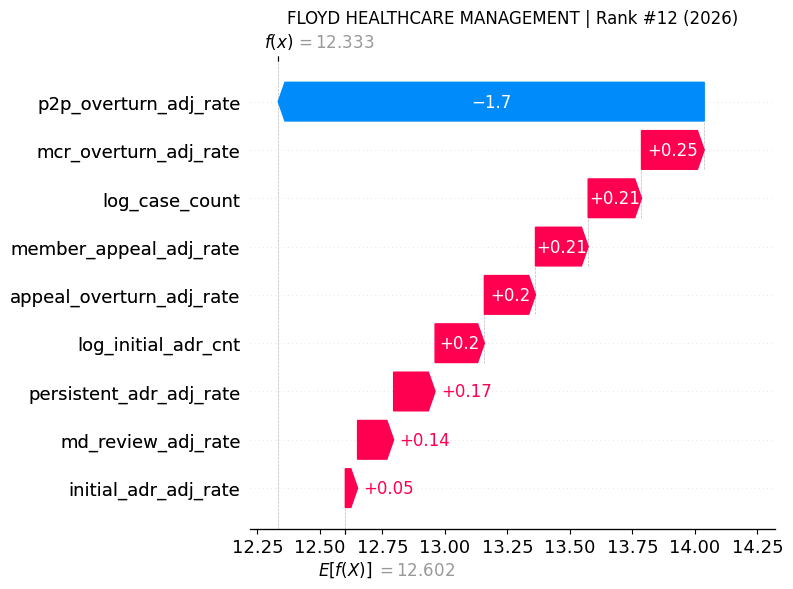

In [14]:
# =============================================================================
# SHAP WATERFALL — TOP 5 per year
# =============================================================================
base_val = float(explainer.expected_value) if np.ndim(explainer.expected_value) == 0 else float(explainer.expected_value[0])

for yr in ["2025", "2026"]:
    yr_mask = df_pooled["year"] == yr
    top5 = (
        df_pooled[yr_mask & df_pooled["anomaly_flag"] & df_pooled["hospital_group"].notna()]
        .nsmallest(5, "anomaly_score")
    )
    for iloc_pos in range(len(top5)):
        row = top5.iloc[iloc_pos]
        pos = df_pooled.index.get_loc(top5.index[iloc_pos])
        if not np.isscalar(pos):
            pos = np.flatnonzero(pos if isinstance(pos, np.ndarray) else df_pooled.index == top5.index[iloc_pos])[0]
        pos = int(pos)
        hospital_name = row["hospital_group"]
        rank = int(row["anomaly_rank"])

        print(f"\n{'=' * 60}")
        print(f"{hospital_name} | Rank #{rank} ({yr})")
        print(f"{'=' * 60}")

        explanation = shap.Explanation(
            values=shap_values[pos],
            base_values=base_val,
            feature_names=iso_kpi
        )
        shap.waterfall_plot(explanation, show=False)
        plt.title(f"{hospital_name[:35]} | Rank #{rank} ({yr})")
        plt.tight_layout()
        plt.show()

In [ ]:
# =============================================================================
# OUTPUT ASSEMBLY
# =============================================================================
# FIX #5: driver_dev_pct — for log-transformed features (log_case_count,
#   log_initial_adr_cnt), deviation is reported as % difference in the ORIGINAL
#   raw count (not in log space). This is intentional: stakeholders interpret
#   "50% above median case volume" more naturally than "0.4 log-units above
#   median log-volume." The model sees log space, but we report in human space.
#   Column is renamed from 'driver_dev' to 'driver_dev_pct' to make clear
#   this is a percentage deviation in original units.
# =============================================================================

adj_rate_cols = [
    "initial_adr_adj_rate", "persistent_adr_adj_rate", "p2p_overturn_adj_rate",
    "appeal_overturn_adj_rate", "mcr_overturn_adj_rate", "md_review_adj_rate",
    "member_appeal_adj_rate"
]
all_rate_cols = [
    "initial_adr_rate", "persistent_adr_rate", "p2p_overturn_rate",
    "appeal_overturn_rate", "mcr_overturn_rate", "md_review_rate",
]
adj_to_raw = dict(zip(adj_rate_cols[:6], all_rate_cols))

df_pooled["driver"] = shap_flagged["shap_driver"].reindex(df_pooled.index).fillna("")

df_pooled["direction"] = np.where(
    df_pooled["anomaly_flag"],
    df_pooled.apply(
        lambda r: "high" if r["driver"] and df_pooled.loc[r.name, r["driver"]] > df_pooled[r["driver"]].median() else "low",
        axis = 1
    ),
    ""
)
df_pooled["reason"] = np.where(
    df_pooled["anomaly_flag"],
    df_pooled["driver"] + " (" + df_pooled["direction"] + ")",
    ""
)

adj_medians = df_pooled[iso_kpi].median()
raw_med_case = df_pooled["case_count"].median()
raw_med_adr = df_pooled["initial_adr_cnt"].median()

df_pooled["driver_value"] = np.nan
df_pooled["driver_adj_median"] = np.nan
df_pooled["driver_raw_median"] = np.nan
df_pooled["driver_dev_pct"] = np.nan

mask = df_pooled["anomaly_flag"] & (df_pooled["driver"] == "log_case_count")
df_pooled.loc[mask, "driver_value"] = df_pooled.loc[mask, "case_count"]
df_pooled.loc[mask, "driver_adj_median"] = raw_med_case
df_pooled.loc[mask, "driver_raw_median"] = raw_med_case
df_pooled.loc[mask, "driver_dev_pct"] = (df_pooled.loc[mask, "case_count"] - raw_med_case) / raw_med_case

mask = df_pooled["anomaly_flag"] & (df_pooled["driver"] == "log_initial_adr_cnt")
df_pooled.loc[mask, "driver_value"] = df_pooled.loc[mask, "initial_adr_cnt"]
df_pooled.loc[mask, "driver_adj_median"] = raw_med_adr
df_pooled.loc[mask, "driver_raw_median"] = raw_med_adr
df_pooled.loc[mask, "driver_dev_pct"] = (df_pooled.loc[mask, "initial_adr_cnt"] - raw_med_adr) / raw_med_adr

for ac in adj_rate_cols:
    mask = df_pooled["anomaly_flag"] & (df_pooled["driver"] == ac)
    if mask.any():
        df_pooled.loc[mask, "driver_value"] = df_pooled.loc[mask, ac]
        df_pooled.loc[mask, "driver_adj_median"] = adj_medians[ac]
        raw_col = adj_to_raw.get(ac)
        if raw_col and raw_col in df_pooled.columns:
            raw_meds = df_pooled[raw_col].median()
            df_pooled.loc[mask, "driver_raw_median"] = raw_meds
        else:
            df_pooled.loc[mask, "driver_raw_median"] = adj_medians[ac]
        df_pooled.loc[mask, "driver_dev_pct"] = (df_pooled.loc[mask, ac] - adj_medians[ac]) / adj_medians[ac]

all_count_cols = list(set(count_cols_25 + count_cols_26))
all_rate_cols_full = list(set(rate_cols_25 + rate_cols_26))

for col in all_count_cols + all_rate_cols_full + iso_kpi:
    if col not in df_pooled.columns:
        df_pooled[col] = 0.0

output_cols = [
    "hospital_group", "fin_market", "year",
    *[c for c in all_count_cols if c in df_pooled.columns],
    *[c for c in all_rate_cols_full if c in df_pooled.columns],
    *iso_kpi,
    "anomaly_score", "anomaly_rank", "percentile_rank", "anomaly_flag",
    "driver", "direction", "reason",
    "driver_value", "driver_adj_median", "driver_raw_median", "driver_dev_pct"
]
df_output = (
    df_pooled[[c for c in output_cols if c in df_pooled.columns]]
    .sort_values("anomaly_score")
    .reset_index(drop = True)
)

print(f"Output: {df_output.shape[0]} rows | Flagged: {df_output['anomaly_flag'].sum()}")
print(f"  2025: {(df_output['year'] == '2025').sum()} rows ({((df_output['year'] == '2025') & df_output['anomaly_flag']).sum()} flagged)")
print(f"  2026: {(df_output['year'] == '2026').sum()} rows ({((df_output['year'] == '2026') & df_output['anomaly_flag']).sum()} flagged)")
df_output[df_output["anomaly_flag"]]

In [ ]:
# =============================================================================
# WRITE TO SNOWFLAKE
# =============================================================================
# from sqlalchemy import create_engine
# from snowflake.sqlalchemy import URL

# engine_write = create_engine(URL(
#     account       = "UHG-UHGDWAAS",
#     user          = "KHANG.NGUYEN@UHC.COM",
#     authenticator = "externalbrowser",
#     role          = "AZU_SDRP_VING_PRD_DEVELOPER_ROLE",
#     warehouse     = "VING_PRD_MNR_HCE_DATAINFRA_WH",
#     database      = "VING_PRD_TREND_DB",
#     schema        = "TMP_1M"
# ))

# df_write = df_output.copy()
# df_write.columns = [c.upper() for c in df_write.columns]

# df_write.to_sql(
#     "kn_loc_if_outlier_hospitals_mnr_2025_2026",
#     engine_write,
#     schema = "TMP_1M",
#     if_exists = "replace",
#     index = False
# )

# engine_write.dispose()

# print(f"Wrote {len(df_write)} rows to TMP_1M.KN_LOC_IF_OUTLIER_HOSPITALS_MNR_2025_2026")
# print(f"  2025: {(df_write['YEAR'] == '2025').sum()} rows")
# print(f"  2026: {(df_write['YEAR'] == '2026').sum()} rows")